<a href="https://colab.research.google.com/github/adasegroup/ML2022_seminars/blob/master/seminar7/seminar_GB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seminar: Gradient Boosting
Course: Machine Learning by professor Evgeny Burnaev
<br>
Author: Alexander Marusov

## Introduction


In this seminar you will
- Make a recap of the theory on the gradient boosting algorithm
- Try standard implementation of gradient boosting from scikit-learn
- Try advanced implementations and understand how they differ from each other: XGBoost, LightGBM, CatBoost

Also you will be able to try to implement the gradient boosting algorithm from scratch

## Gradient Boosting theory

### Main statements about Decision Trees, Bagging and Random Forests

- **DECISION TREES**.
With increasing the *max_depth* parameter the training loss of decision tree will be closer to zero, but test loss is high. This means, that our model has bad generalization capability and we have **overfitting**. Consequently, we need somehow to prevent overfitting. Of course we can choose the best *max_depth* parameter according to test, but it is not the only solution.

- **BAGGING = DECISION TREE + BOOTSTRAP**.
We can use several decision trees, which are trained on different train sets, which were received using bootstrap procedure. Bootsrapped dataset contains the same number of samples as original data but some of them are included with some number of their copies, and some of them are not included. To make a final prediction we will average predictions across decision trees. Since we will have different trees, the predictions will be more or less independent and, consequently, overfitting will be decreased.

- **RANDOM FOREST = BAGGING + DIFFERENT FEATURES**.
To increase generalization capability of the model (by making assumption about independency of trees stronger) we want to take not only different samples, but also different features as well. In Random Forest we have several decision trees, which are trained not only on different train samples, but also on different features as well.

The main disadvantage of the ensembles above is that the learning process is undirected, i.e. decision trees don't know anything about mistakes of the others models. To eliminate this problem we will try the **Boosting** idea.

### The problem statement


The solution is found in the form of sum over random trees $h_m(x)$,
$$F(x) = \sum_{m=1}^{M} h_m(x).$$

The additive model is built in a greedy fashion:
$$f_m(x) = f_{m-1}(x) + h_m(x).$$

Having loss function $L(y, f)$, we find every new tree from the optimization
$$h_m =  \arg\min_{h} \sum_{i=1}^{n} L(y_i, f_{m-1}(x_i) + h(x_i)).$$









### How the problem is solved


#### Gradient Boosting

The initial model $f_0(x)$ is problem specific, for least-squares regression one usually chooses the mean of the target values.

To solve the task above we should divide into two parts:

- At the beggining we should find values $s_i$, which our random trees should have on the data $x_i$, i.e. $s_i = h(x_i)$. To solve this task we should find minimum of $F(s):$
$$F(s) =  \sum_{i=1}^{n} L(y_i, f_{m-1}(x_i) + s_i)).$$ Here $s = (s_1, s_2, ... , s_n)$. As we know from the math, the gradient of the function will show the direction of the highest increase of the function. Since we want to minimize the function, we should go in the direction, which is opposite to the gradient. This direction is also-called **antigradient**. Currently $s = (0, 0, ... , 0)$, because $$F(0) =  \sum_{i=1}^{n} L(y_i, f_{m-1}(x_i)))$$ So we need to make a gradient step from fucntion $F$ in point $s = (0, 0, ... , 0)$. The gradient step is the next formula: $$s_{new} = s_{old} - \nabla F(s)|_{s=s_{old}}$$ Since $s_{old} = (0, 0, ... , 0)$, the components of new vector $s$ should be: $$s_{new_i} = -\frac{\partial L(y_i, f_{m-1}(x_i))}{\partial f_{m-1}(x_i)}.$$

- After that we can find $h_m(x)$ just by solving usual supervised learning task with the data $(x_1, s_1), (x_2, s_2), ..., (x_n, s_n)$.


Before the final step in some versions of Gradient Boosting you should find $$\gamma_m = \arg\min_{\gamma} \sum_{i=1}^{n} L(y_i, f_{m-1}(x_i)
- \gamma \frac{\partial L(y_i, f_{m-1}(x_i))}{\partial f_{m-1}(x_i)})$$ Finally, $$f_m(x) = f_{m-1}(x) + \nu \gamma_m h_m(x)$$



Also there can be just simple sum $f_m(x) = f_{m-1}(x) + h_m(x)$

#### AdaBoost

**Question:** Why AdaBoost is an adaptive algorithm?

The underlying idea of boosting is to combine **cheap - weak** predictiors into a strong **powerful ensemble**.

![](https://www.researchgate.net/profile/Eiji_Hato/publication/264713074/figure/fig5/AS:614118558023749@1523428682764/Concept-of-AdaBoost.png)

**Main idea**: we have several weak classifiers. Each of them learns on mistakes from the previous steps by fitting on those data samples which were mistaken the most (weight $ω_i^{m}$ in pseudocode below). As a result each classifier can classify some samples correctly and others incorrect. Hence the final decision is a weighted (weight $α_m$ in pseudocode below) sum of votes.

AdaBoost pseudo code

<img src=https://towardsdatascience.com/wp-content/uploads/2021/02/19NjSsLHRSXUwl0cyvKbWGQ.png>

## Classification task with Gradient Boosting


We will work with a set of banking data.

Objects — bank clients. Features — characteristics of clients and clients' relationships with the bank.

The target variable is `Personal Loan`.
We will predict whether the client has taken a loan. This is a **binary classification** task.

Import libraries

In [ ]:
! pip install catboost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)

import warnings

warnings.filterwarnings("ignore")


Get data for task

In [ ]:
data_path = 'https://raw.githubusercontent.com/Gaechka777/data/main/Bank_Personal_Loan_Modelling.csv'
data = pd.read_csv(data_path, index_col=0)
data.head()

Define useful variables

In [ ]:
target_name = "Personal Loan"
rand_state = 123

Let's split our data into train and test.

* train - the slice on which we will train the model
* test - the slice on which we will evaluate the quality of our model

In EDA we will analyse only train. EDA helps to find useful insights in the data that will help with prediction. If we extract useful insights from test, we can't honestly assess the quality.



##### Task 1

Split data into test and training samples at fixed random state and in the proportion 70:30.

In [ ]:
# HERE IS YOUR CODE
# X_train, X_test, y_train, y_test = ...

### EDA

#### Overview

Amount of data we have

In [ ]:
X_train.shape

Features we have

In [ ]:
X_train.columns

Feature Description:
- ID: The client's identification number
- Age: Age of the client
- Experience: Number of years of professional experience
- Income: Annual income of the client
- ZIP Code: Postcode of home address
- Family: Client's family size
- CCAvg: Average credit card spending per month.
- Education: Level of education. 1: Undergrad; 2: Graduate; 3:Advanced/Professional
- Mortgage: Cost of home mortgage, if any
- Personal Loan: Did this client accept a personal loan offered in the last campaign?
- Securities Account: Does this client have a securities account with a bank?
- CD Account: Does this client have a certificate of deposit (CD) with a bank?
- Online: Does the client use internet banking services?
- Credit card: Does the client use a credit card issued by the bank?


#### Data types research

Features types we have

In [ ]:
X_train.info()

All features have numeric data types (float, int), but that doesn't mean we don't have categorical data. Let's look at the distribution graphs of features and match it with the feature description.

In [ ]:
X_train.hist(figsize=(20, 20), bins=100)
pass

For example, the `Education` has only 3 unique values. According to the feature description, `Education` means Level of education.
1: Undergrad; 2: Graduate; 3:Advanced/Professional. That's a categorical feature.

Let us consider as categorical those features that have unique values < 5, otherwise the continuous

In [ ]:
categorical = [col for col in X_train.columns if X_train[col].nunique() <= 5]
continuous = [col for col in X_train.columns if X_train[col].nunique() > 5]

In [ ]:
print(categorical)
print(continuous)

Let's look at categorical features

In [ ]:
fig = plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical):
    ax = fig.add_subplot(2, 3, i + 1)
    sns.countplot(x=col, data=X_train, palette="Set2")

Let's look at numeric features

In [ ]:
fig = plt.figure(figsize=(30, 20))
for i, col in enumerate(continuous):
    ax = fig.add_subplot(3, 3, i + 1)
    sns.distplot(X_train[col])

Let's look at the target column

In [ ]:
sns.countplot(x=target_name, data=pd.DataFrame(y_train), palette="Set2")

Our data is highly unbalanced, but in our methods we will use tools to work with it.

#### Missing values analysis

##### Task 2

Calculate percentage of missing values in each feature column

In [ ]:
# HERE IS YOUR CODE

#### Correlation analysis

In [ ]:
corr = X_train.corr()
plt.figure(figsize=(20, 20))
plt.title("Correlation")
ax = sns.heatmap(corr, annot=True, square=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

The corrrelation matrix show us that `CD Account`, `CCAvg`, `Income` affect the target quite strongly compared to the others. Judging by the description of these features, all of them are related to the income or expenses of the client, which directly affects the decision to take a loan. Also there is the correlation of `Age` with `Experience`, therefore, one of them we will remove.

In [ ]:
X_train = X_train.drop('Age', axis=1)

**Summary of quick EDA:**

1. We have 6 categorical features and 7 numeric.
2. Our classification task is highly unbalanced, we will use methods in prediction algorithms to work with it.
2. There are no missing values, no need to fill
3. There is a strong correlation between Age and Experience, we dropped Age feature

### Preprocessing

At Preprocessing stage we should apply transformations we decided to apply after EDA or apply transformations related to using a specific machine learning algorithm.

Based on EDA there is only one thing we need to apply to our testing data - to remove `Age` feature. And we do not have specific transformations for future algorithms.

In [ ]:
X_test = X_test.drop('Age', axis=1)

### Training

Let's write a function that will evaluate the quality of future predictions

In [ ]:
def evaluate(
    y,
    preds,
    stage="test",
    model_name="",
    need_report=True,
    need_roc_auc=False,
    y_prob=None,
):
    print(f"Accuracy ({stage}): {accuracy_score(y, preds):.3f}")
    print(f"F1 ({stage}): {f1_score(y, preds):.3f}")

    if need_report:
        print(classification_report(y, preds))

    if need_roc_auc:
        fpr, tpr, thresholds = roc_curve(y, y_prob)

        auc = roc_auc_score(y, y_prob)

        plt.plot(fpr, tpr, label=f"{model_name} {stage} (AUC = {auc:.2f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False positives ")
        plt.ylabel("True positives")
        plt.title("ROC-curve")
        plt.legend()
        plt.show()


#### Baseline

As for baseline we will use Logistic regression

We will compare gradient boosting algorithms with the baseline

In [ ]:
# Training
log_model = LogisticRegression(random_state=rand_state, class_weight='balanced')
log_model.fit(X_train, y_train)

# Prediction
preds_train = log_model.predict(X_train)
preds_test = log_model.predict(X_test)

# Evaluating on train
y_prob_train = log_model.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train, stage='train', model_name='LogisticRegression', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train)

In [ ]:
# Evaluating on test
y_prob_test = log_model.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test, stage='test', model_name='LogisticRegression', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test)

At baseline we have really good AUC score (0.95), but bad F1-score (0.57) because we predict class 1 badly

#### AdaBoost

The AdaBoost approach from scikit-learn:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
# Training
model_adaboost = AdaBoostClassifier(random_state=rand_state)
model_adaboost.fit(X_train, y_train)

# Prediction
preds_train_boost = model_adaboost.predict(X_train)
preds_test_boost = model_adaboost.predict(X_test)

# Evaluating on train
y_prob_train_boost = model_adaboost.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_boost, stage='train', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_boost)

In [ ]:
# Evaluating on test
y_prob_test_boost = model_adaboost.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_boost, stage='test', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_boost)

AdaBoost approach is better than baseline, but not enough.

AUC score increased from 0.95 to 0.98 and F1 score increased from baseline 0.58 to 0.8.

#### Gradient Boosting

The most basic approach is gradient boosting from scikit-learn:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Training
model_boosting = GradientBoostingClassifier(random_state=rand_state)
model_boosting.fit(X_train, y_train)

# Prediction
preds_train_boost = model_boosting.predict(X_train)
preds_test_boost = model_boosting.predict(X_test)

# Evaluating on train
y_prob_train_boost = model_boosting.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_boost, stage='train', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_boost)

In [ ]:
# Evaluating on test
y_prob_test_boost = model_boosting.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_boost, stage='test', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_boost)

Basic gradient boosting approach is much better than Adaboost.

AUC score increased from 0.98 to 1.0 and F1 score increased from Adaboost 0.8 to 0.92.

##### Hyperparametres tuning

We used `GradientBoostingClassifier` with default parameters, but it is possible to choose parameters that will improve the quality on test. As an example, let's see how this can be implemented using `GridSearchCV` from scikit-learn

In [ ]:
from sklearn.model_selection import GridSearchCV

clf = GradientBoostingClassifier(random_state=rand_state)

param_grid = {'n_estimators' : [80, 100, 500],
              'max_depth': [ 5, 7, 10]}

clf = GridSearchCV(clf, param_grid, cv=5, scoring="f1")

In [ ]:
%%time
clf.fit(X_train, y_train)

In [ ]:
clf.best_params_

In [ ]:
# Prediction
preds_train_boost = clf.predict(X_train)
preds_test_boost = clf.predict(X_test)

In [ ]:
# Evaluating on train
y_prob_train_boost = clf.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_boost, stage='train', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_boost)

In [ ]:
# Evaluating on test
y_prob_test_boost = clf.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_boost, stage='test', model_name='GradientBoostingClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_boost)

With hyperparametres we achieved 0.93 F1-score, the previous was 0.92


Let's plot dependencies of quality on hyperparameters

In [ ]:
results = clf.cv_results_
df = pd.DataFrame(results)

In [ ]:
# param = n_estimators
plt.figure(figsize=(8, 6))
sns.lineplot(x='param_n_estimators', y='mean_test_score', data=df, ci=None)
plt.xlabel('n_estimators')
plt.ylabel('Average quality')
plt.title('Quality dependence on n_estimators')
plt.show()

In [ ]:
# param = max_depth
plt.figure(figsize=(8, 6))
sns.lineplot(x='param_max_depth', y='mean_test_score', data=df, ci=None)
plt.xlabel('max_depth')
plt.ylabel('Average quality')
plt.title('Quality dependence on n_estimators')
plt.show()

##### Feature importance

In [ ]:
feature_importances = model_boosting.feature_importances_

features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

features_df = features_df.sort_values(by='Importance', ascending=True)

In [ ]:
plt.figure(figsize=(12, 8))
plt.barh(range(len(features_df)), features_df['Importance'], align='center', color='lightblue')
plt.title("Top Features by Importance")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.yticks(range(len(features_df)), features_df['Feature'])
plt.tight_layout()
plt.show()

We can see that Income and Education are more important to understand whether the client has taken a loan

#### Realizations

We will try popular realizations of gradient boosting algorithms that often better in quality and speed that basic approach

##### LightGBM


LightGBM uses a histogram-based approach to speed up the training process, which can be a major advantage when dealing with large datasets. The histogram approach groups data into bins, reducing the number of calculations needed to build decision trees. This results in faster training times and more efficient use of resources.

LightGBM builds trees by levels, but does so asymmetrically, based on the distribution of the data, in order to optimally partition the feature space.

More details: https://lightgbm.readthedocs.io/en/stable/



In [ ]:
import lightgbm as lgb

In [ ]:
%%time
# Training
model_xgb = lgb.LGBMClassifier(random_state=rand_state, class_weight='balanced')
model_xgb.fit(X_train, y_train)

In [ ]:
# Prediction
preds_train_xgb = model_xgb.predict(X_train)
preds_test_xgb = model_xgb.predict(X_test)

# Evaluating on train
y_prob_train_xgb = model_xgb.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_xgb, stage='train', model_name='XGBClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_xgb)

In [ ]:
# Evaluating on test
y_prob_test_xgb = model_xgb.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_xgb, stage='test', model_name='XGBClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_xgb)

##### XGBoost

XGBoost builds trees sequentially by levels until the maximum depth is reached. There is no separate constraint on the number of nodes, as it is derived from the depth constraint. In XGBoost, trees ‘tend’ to be symmetric in depth, and ideally a complete binary tree is obtained if this does not contradict other constraints (such as the minimum number of objects in the leaf). Such trees are usually more resistant to overfitting.

More details: https://xgboost.readthedocs.io/en/latest/

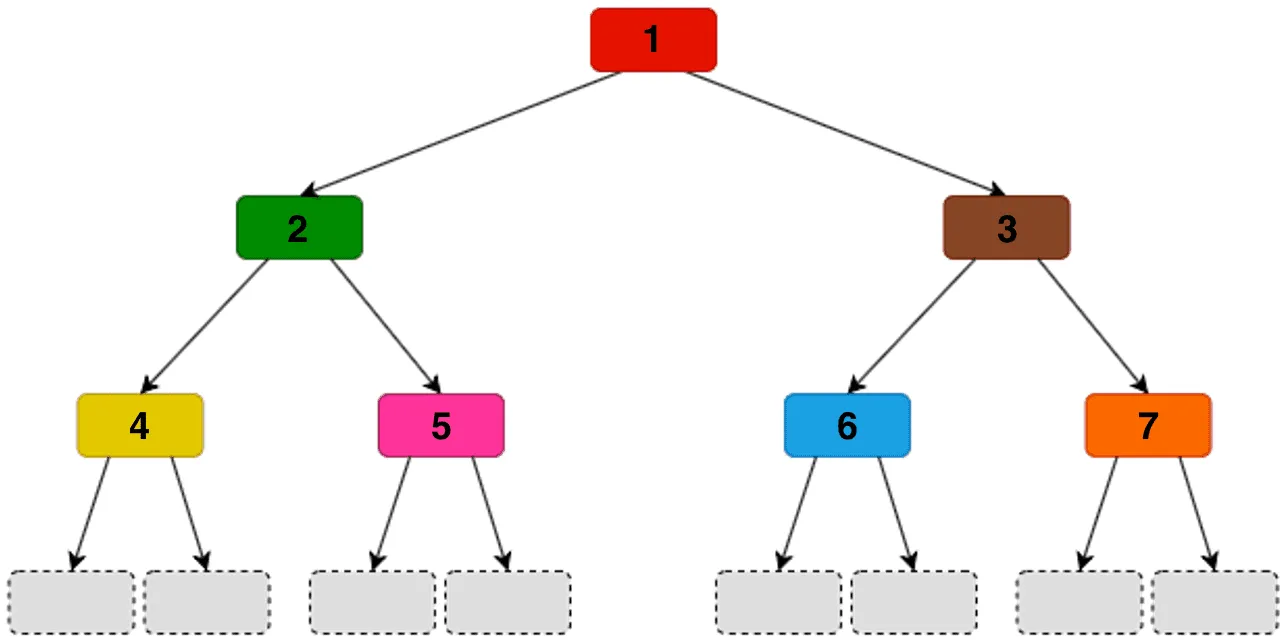

In [ ]:
from xgboost import XGBClassifier

In [ ]:
%%time
# Training
model_xgb = XGBClassifier(random_state=42, class_weight='balanced')
model_xgb.fit(X_train, y_train)

In [ ]:
# Prediction
preds_train_xgb = model_xgb.predict(X_train)
preds_test_xgb = model_xgb.predict(X_test)

# Evaluating on train
y_prob_train_xgb = model_xgb.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_xgb, stage='train', model_name='XGBClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_xgb)

In [ ]:
# Evaluating on test
y_prob_test_xgb = model_xgb.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_xgb, stage='test', model_name='XGBClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_xgb)

##### CatBoost

CatBoost is a lib containing a modification of the gradient boosting model from Yandex Company. The main feature of the algorithm is its ability to efficiently process categorical variables.

CatBoost builds trees according to the principle: ‘All vertices of the same level have the same predicate’. The identical splits in all vertices of one level allow to get rid of branching (if-else constructions) in the code of inference of the model by means of bit operations and to receive more effective code which in times accelerates application of the model, especially in case of application on batches.

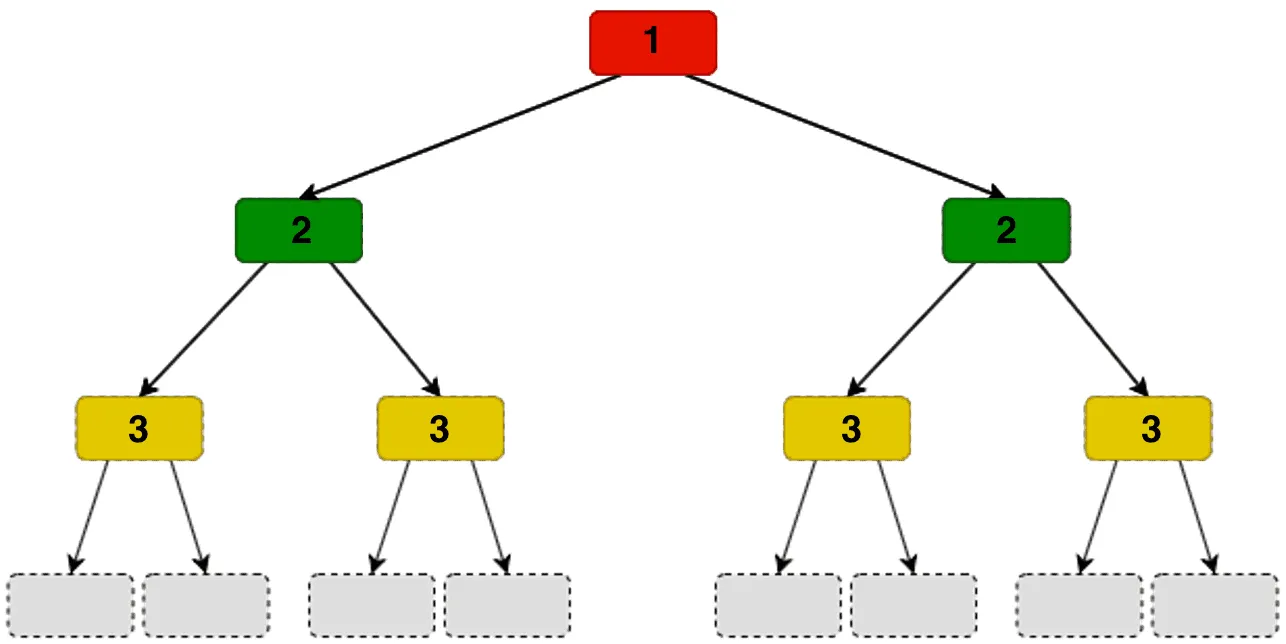

In [ ]:
import catboost
from catboost import CatBoostClassifier

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# define classes and calculate balancing weights for them
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [ ]:
%%time
# Training
model_catboost = CatBoostClassifier(verbose=0, class_weights=class_weights)
model_catboost.fit(X_train, y_train)

In [ ]:
# Prediction
preds_train_cat = model_catboost.predict(X_train)
preds_test_cat = model_catboost.predict(X_test)

# Evaluating on train
y_prob_train_cat = model_catboost.predict_proba(X_train)[:, 1]
evaluate(y_train, preds_train_cat, stage='train', model_name='CatBoostClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_train_cat)

In [ ]:
# Evaluating on test
y_prob_test_cat = model_catboost.predict_proba(X_test)[:, 1]
evaluate(y_test, preds_test_cat, stage='test', model_name='CatBoostClassifier', need_report=True,
         need_roc_auc=True, y_prob=y_prob_test_cat)

###### Task 3: Learn how to get features importance in Catboost

1.   Use Catboost documentation(https://catboost.ai/docs/en/concepts/fstr) to understand how to get features importance in Catboost
2.   Print a sorted list of features and their importances, from largest to smallest


In [ ]:
# HERE IS YOUR CODE

### Summary

In the seminar we
* repeated the theory on gradient boosting and trees
* tried the basic approach with default parameters from scikit-learn
* tried to select hyperparameters to improve quality and analysed possible features importance
* tried popular gradient boosting algorithms: LightGBM, XGBoost, Catboost

### Bonus tasks

In this section you can practice with realizing algorithms from scratch

#### Task 1: Realizing Gradient Boosting from scratch

You will have to implement the gradient boosting algorithm from scratch.
To make things easier, we have defined a template for your algorithm.

Yor implementation will have the following features:
* Since the models learn to predict the gradient, we will need basic **regressors** instead of base classifiers, we use regression trees from `sklearn'
* Constant lerning rate (gamma) to combat overtraining and simplify implementation
* Only binary classification will be implemented, since the gradient on the model predictions in the case of multi-class classification is a vector on the number of classes, we will need `K` regression trees at each step (each of them can only predict one number). Keep this in mind when using gradient boosting from `sklearn`: in it, the number of trees that make up the model is actually equal to the number_of_classes * `n_estimators`. There is no such problem for the binary case, since a single number is sufficient to predict binary probability
* Our implementation relies on logits - the raw predictions of the regression model taking real values.
* As a loss function, we will take the negative We have the following formulas:
$$
    \text{model}(x) = h, \ \text{probability} = \sigma(h) \\\
    \mathcal{L}(\text{model}, X, Y) = -\sum_{(x, y) \in X\oplus Y} y \cdot\log(\text{probability}(\text{model}(x))) + (1 - y) \cdot \log(1 - \text{probability}(\text{model}(x))))
$$

Use numerically stable mathematical operations or add epsilon or clip probability values to avoid divisions by zero and under the logarithm.

In [ ]:
class MyBinaryTreeGradientBoostingClassifier:
    """
    *Binary* gradient boosting with trees using
    negative log-likelihood loss with constant learning rate.
    Trees are to predict logits.
    """
    big_number = 1 << 32
    eps = 1e-8

    def __init__(
            self,
            n_estimators: int,
            learning_rate: float,
            seed: int,
            **kwargs
    ):
        """
        :param n_estimators: estimators count
        :param learning_rate: hard learning rate
        :param seed: global seed
        :param kwargs: kwargs of base estimator which is sklearn TreeRegressor
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.initial_logits = None
        self.rng = np.random.default_rng(seed)
        self.base_estimator = DecisionTreeRegressor
        self.base_estimator_kwargs = kwargs
        self.estimators = []
        self.loss_history = []  # this is to track model learning process

    def create_new_estimator(self, seed):
        return self.base_estimator(**self.base_estimator_kwargs, random_state=seed)

    @staticmethod
    def cross_entropy_loss(
            true_labels: np.ndarray,
            logits: np.ndarray
    ):
        """
        compute negative log-likelihood for logits,
        use clipping for logarithms with self.eps
        or use numerically stable special functions.
        This is used to track model learning process
        :param true_labels: [n_samples]
        :param logits: [n_samples]
        :return:
        """
        # ...
        # return nll
        pass

    @staticmethod
    def cross_entropy_loss_gradient(
            true_labels: np.ndarray,
            logits: np.ndarray
    ):
        """
        compute gradient of log-likelihood w.r.t logits,
        use clipping for logarithms with self.eps
        or use numerically stable special functions
        :param true_labels: [n_samples]
        :param logits: [n_samples]
        :return:
        """
        # ...
        # return gradient
        pass

    def fit(
            self,
            X: np.ndarray,
            y: np.ndarray
    ):
        """
        sequentially fit estimators to reduce residual on each iteration
        :param X: [n_samples, n_features]
        :param y: [n_samples]
        :return: self
        """
        # self.loss_history = []
        # # only should be fitted on datasets with binary target
        # assert (np.unique(y) == np.arange(2)).all()
        # # init predictions with mean target (mind that these are logits!)
        # self.initial_logits = # YOUR CODE IS HERE
        # # create starting logits
        # # logits = # YOUR CODE IS HERE
        # # init loss history with starting negative log-likelihood
        # # self.loss_history.append(self.cross_entropy_loss(y, logits))
        # # sequentially fit estimators with random seeds
        # for seed in self.rng.choice(
        #         max(self.big_number, self.n_estimators),
        #         size=self.n_estimators,
        #         replace=False
        # ):
        #     # add newly created estimator
        #     self.estimators.append(self.create_new_estimator(seed))
        #     # compute gradient
        #     gradient = # YOUR CODE IS HERE
        #     # fit estimator on gradient residual
        #     # YOUR CODE IS HERE
        #     # adjust logits with learning rate
        #     # YOUR CODE IS HERE
        #     # append new loss to history
        #     self.loss_history.append(self.cross_entropy_loss(y, logits))
        # return self

    def predict_proba(
            self,
            X: np.ndarray
    ):
        """
        :param X: [n_samples]
        :return:
        """
        # init logits using precalculated values
        # logits = ...
        # sequentially adjust logits with learning rate
        # for estimator in self.estimators:
        #      ...
        # don't forget to convert logits to probabilities
        # return probas
        pass

    def predict(
            self,
            X: np.ndarray
    ):
        """
        calculate predictions using predict_proba
        The threshold for determining the class based on probability is 0.5 (strictly greater than 0.5)
        :param X: [n_samples]
        :return:
        """
        # ...
        # return predictions

How to check yourself

Run the code below where your classifier is trained. The AUC must be at least 0.8

In [ ]:
# # Training
# your_model = MyBinaryTreeGradientBoostingClassifier(n_estimators=10, learning_rate=1.0, seed=42, max_depth=4)
# your_model.fit(X_train, y_train)

# # Prediction
# preds_train_boost = your_model.predict(X_train)
# preds_test_boost = your_model.predict(X_test)

# # Evaluating on train
# y_prob_train_boost = your_model.predict_proba(X_train)
# evaluate(y_train, preds_train_boost, stage='train', model_name='GradientBoostingClassifier', need_report=True,
#          need_roc_auc=True, y_prob=y_prob_train_boost)

In [ ]:
# # Evaluating on test
# y_prob_test_boost = your_model.predict_proba(X_test)
# evaluate(y_test, preds_test_boost, stage='test', model_name='GradientBoostingClassifier', need_report=True,
#          need_roc_auc=True, y_prob=y_prob_test_boost)

#### Task 2: Kaggle

You should predict probability that somebody will experience financial distress in the next two years

Take data from https://www.kaggle.com/c/GiveMeSomeCredit

The description of variables you can find also here https://www.kaggle.com/c/GiveMeSomeCredit

Follow all the steps to get the prediction and send it to Kaggle
* Exlorate your with EDA approach (look at data types, missing values, correlations between features)
* Try a simple model as baseline (if it's a classification task you can use Logistic Regression)
* Try different implementations of boosting, try to change hyperparameters with GridCV approach, try select features with top feature importance
* Create a table with your best predictions and submit it to Kaggle leaderboard to see the results of your work!

Below you can find help code cells!

##### 1 - Get data for this task

In [ ]:
# train_path = 'https://raw.githubusercontent.com/adasegroup/ML2022_seminars/master/seminar5/give_me_some_credit.csv'
# test_path = 'https://raw.githubusercontent.com/Astralex98/Give-me-some-credit-Kaggle-/main/cs-test.csv'

# df_train = pd.read_csv(train_path, index_col=0)
# df_kaggle_test = pd.read_csv(test_path, index_col=0)

##### 2 - How to create submit to Kaggle

In [ ]:
# predictions = [] # for example there is a list of your predictions

In [ ]:
# sub = pd.read_csv('https://raw.githubusercontent.com/Astralex98/Give-me-some-credit-Kaggle-/main/sampleEntry.csv')
# sub['Probability']= predictions
# sub.to_csv('MySubmission.csv', index=False)
# sub

Now you have a csv-file you can send to kaggle!